In [1]:
import pandas as pd
import numpy as np

avax_preds = pd.read_csv('Coin_Models/avax_orders.csv')
near_preds = pd.read_csv('Coin_Models/near_orders.csv')
sol_preds = pd.read_csv('Coin_Models/sol_orders.csv')
dot_preds = pd.read_csv('Coin_Models/dot_orders.csv')
matic_preds = pd.read_csv('Coin_Models/matic_orders.csv')

avax_prices = pd.read_parquet('data/price_data/processed/aval_processed_data.parquet')
dot_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/dot_price_processed.parquet')
matic_prices = pd.read_parquet('data/price_data/processed/matic_processed_data.parquet')
near_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/near_price_processed.parquet')
sol_prices = pd.read_parquet('data/price_data/processed/sol_processed_data.parquet')

In [2]:
dot_prices['time_period_end'] = dot_prices.index
dot_prices.index = np.arange(len(dot_prices))

near_prices['time_period_end'] = near_prices.index
near_prices.index = np.arange(len(near_prices))

In [3]:
# Define the split index for 70% training data
split_index = len(avax_preds)
avax_prices = avax_prices[-split_index:].reset_index().drop(columns=['index'])
avax_preds['time'] = avax_prices['time_period_end']
avax_preds = avax_preds[(avax_preds['time'] >= '2024-01-01') & (avax_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
avax_prices = avax_prices[(avax_prices['time_period_end'] >= '2024-01-01') & (avax_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(near_preds)
near_prices = near_prices[-split_index:].reset_index().drop(columns=['index'])
near_preds['time'] = near_prices['time_period_end']
near_preds = near_preds[(near_preds['time'] >= '2024-01-01') & (near_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
near_prices = near_prices[(near_prices['time_period_end'] >= '2024-01-01') & (near_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(sol_preds)
sol_prices = sol_prices[-split_index:].reset_index().drop(columns=['index'])
sol_preds['time'] = sol_prices['time_period_end']
sol_preds = sol_preds[(sol_preds['time'] >= '2024-01-01') & (sol_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
sol_prices = sol_prices[(sol_prices['time_period_end'] >= '2024-01-01') & (sol_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(dot_preds)
dot_prices = dot_prices[-split_index:].reset_index().drop(columns=['index'])
dot_preds['time'] = dot_prices['time_period_end']
dot_preds = dot_preds[(dot_preds['time'] >= '2024-01-01') & (dot_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
dot_prices = dot_prices[(dot_prices['time_period_end'] >= '2024-01-01') & (dot_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(matic_preds)
matic_prices = matic_prices[-split_index:].reset_index().drop(columns=['index'])
matic_preds['time'] = matic_prices['time_period_end']
matic_preds = matic_preds[(matic_preds['time'] >= '2024-01-01') & (matic_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
matic_prices = matic_prices[(matic_prices['time_period_end'] >= '2024-01-01') & (matic_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

In [4]:
dfs = {
    "AVAX": avax_preds,
    "NEAR": near_preds,
    "SOL": sol_preds,
    "DOT": dot_preds,
    "MATIC": matic_preds
}

price_dfs = {
    "AVAX": avax_prices,
    "DOT": dot_prices,
    "MATIC": matic_prices,
    "NEAR": near_prices,
    "SOL": sol_prices
}

In [5]:
avax_preds.drop(columns='Unnamed: 0', inplace=True)
near_preds.drop(columns='Unnamed: 0', inplace=True)
sol_preds.drop(columns='Unnamed: 0', inplace=True)
dot_preds.drop(columns='Unnamed: 0', inplace=True)
matic_preds.drop(columns='Unnamed: 0', inplace=True)

In [6]:
'''import pandas as pd
import matplotlib.pyplot as plt

def calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts for each coin based on predicted classifications and probabilities,
    with capital constraints.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin
    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin

    all_results = {} # store results for all coins

    for coin, df in dfs.items():
        results = [] # store results for current coin
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100

            investment_amount = 0
            trading_fee = 0.001

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + (trading_fee * investment_amount)
                    coin_holdings[coin] += investment_amount # track stock holdings
                else:
                    investment_amount = 0 # no cash, no buy

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                  investment_amount = -min(available_holdings, max_investment_per_coin * prob_sell)
                  coin_investments[coin] += investment_amount
                  coin_cash[coin] -= investment_amount # add cash from sale
                  coin_holdings[coin] += investment_amount # reduce stock holdings
                else:
                  investment_amount = 0 # no stock, no sell

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    total_investment = pd.Series([0] * len(next(iter(results.values())))) # initialize with zeros

    for coin_result in results.values():
        total_investment += coin_result['Investment'].cumsum()

    pnl = total_investment
    cumulative_capital = initial_capital + pnl
    return pnl, cumulative_capital

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names) # use number of coins

results = calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)'''

'import pandas as pd\nimport matplotlib.pyplot as plt\n\ndef calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):\n    """\n    Calculates investment amounts for each coin based on predicted classifications and probabilities,\n    with capital constraints.\n    """\n\n    max_investment_per_coin = starting_capital / portfolio_size\n    coin_investments = {coin: 0 for coin in coin_names}\n    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin\n    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin\n\n    all_results = {} # store results for all coins\n\n    for coin, df in dfs.items():\n        results = [] # store results for current coin\n        for index, row in df.iterrows():\n            prediction = row["Prediction"]\n            prob_buy = row["Probability Buy"] / 100\n            prob_sell = row["Probability Sell"] / 100\n\n            investment_amount = 0\n            trading_f

{'AVAX':       Prediction  Probability Buy  Probability Sell  Investment  \
 0            2.0         0.085139          0.463681         0.0   
 1            0.0         0.082291          0.427662         0.0   
 2            2.0         0.089812          0.466062         0.0   
 3            0.0         0.072257          0.384954         0.0   
 4            0.0         0.060939          0.314318         0.0   
 ...          ...              ...               ...         ...   
 6043         1.0         0.964441          0.005760         0.0   
 6044         1.0         0.975830          0.003840         0.0   
 6045         1.0         0.953607          0.007307         0.0   
 6046         1.0         0.943280          0.010137         0.0   
 6047         1.0         0.962524          0.005542         0.0   
 
       Cash Holdings  Stock Holdings    Coin Value  Total Portfolio Value  
 0           20000.0        0.000000      0.000000          100000.000000  
 1           20000.0  

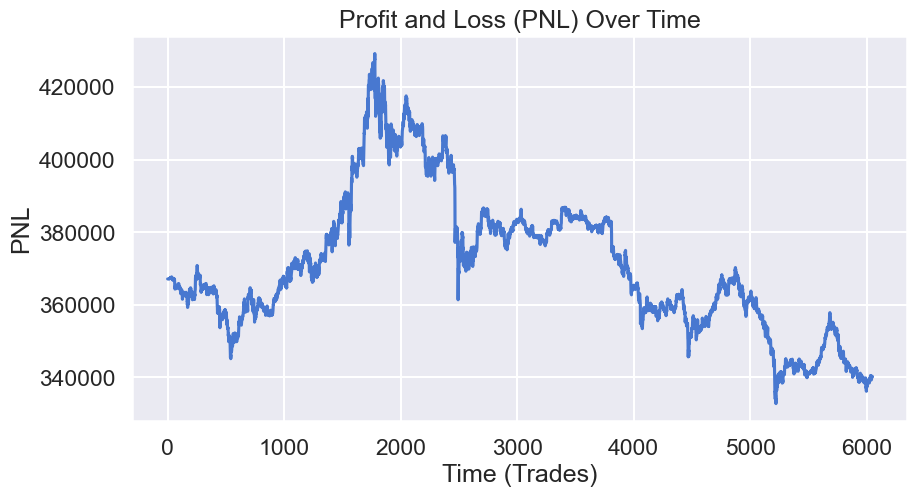

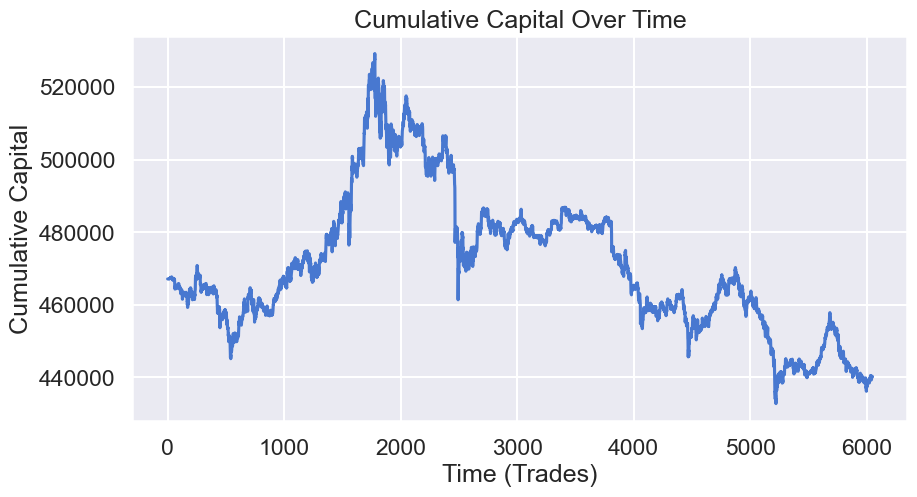


AVAX Results:
      Prediction  Probability Buy  Probability Sell  Investment  \
0            2.0         0.085139          0.463681         0.0   
1            0.0         0.082291          0.427662         0.0   
2            2.0         0.089812          0.466062         0.0   
3            0.0         0.072257          0.384954         0.0   
4            0.0         0.060939          0.314318         0.0   
...          ...              ...               ...         ...   
6043         1.0         0.964441          0.005760         0.0   
6044         1.0         0.975830          0.003840         0.0   
6045         1.0         0.953607          0.007307         0.0   
6046         1.0         0.943280          0.010137         0.0   
6047         1.0         0.962524          0.005542         0.0   

      Cash Holdings  Stock Holdings    Coin Value  Total Portfolio Value  
0           20000.0        0.000000      0.000000          100000.000000  
1           20000.0        0.0

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    all_results = {}


    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100
            current_price = price_df.loc[index, 'Close']# if index in price_df.index else price_df['Close'].iloc[price_df.index.get_loc(index, method='ffill')] # get current price, ffill if missing

            investment_amount = 0

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    units_bought = investment_amount / current_price
                    coin_holdings[coin] += units_bought
                else:
                    investment_amount = 0

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                    sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                    units_sold = min(available_holdings, sell_value / current_price)
                    investment_amount = -units_sold * current_price
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    coin_holdings[coin] -= units_sold
                else:
                    investment_amount = 0

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

display(results)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    print(result_df)

In [32]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import sys
#
# def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names, stop_loss_pct=5):
#     """
#     Calculates investment amounts and PNL for each coin, incorporating price data and stop-loss strategy.
#
#     Parameters:
#     dfs (dict): Dictionary of DataFrames containing signals for each coin
#     price_dfs (dict): Dictionary of DataFrames containing price data for each coin
#     starting_capital (float): Initial investment amount
#     portfolio_size (int): Number of coins in portfolio
#     coin_names (list): List of coin names
#     stop_loss_pct (float): Stop loss percentage (default 5%)
#
#     Returns:
#     dict: Dictionary of DataFrames with portfolio results for each coin
#     """
#     max_investment_per_coin = starting_capital / portfolio_size
#     coin_investments = {coin: 0 for coin in coin_names}
#     coin_cash = {coin: max_investment_per_coin for coin in coin_names}
#     coin_holdings = {coin: 0 for coin in coin_names}
#     coin_values = {coin: 0 for coin in coin_names}
#     coin_entry_price = {coin: None for coin in coin_names}  # Store initial buy price per coin
#     all_results = {}
#
#     stop_loss_pct /= 100  # Convert to decimal for calculations
#
#     for coin, df in dfs.items():
#         results = []
#         price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
#         price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
#         price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
#         df['time'] = pd.to_datetime(df['time']) # ensure datetime
#         price_df = price_df.set_index('time') # set index to time
#         df = df.set_index('time') # set index to time
#
#         for index, row in df.iterrows():
#             prediction = row["Prediction"]
#             prob_buy = row["Probability Buy"] / 100
#             prob_sell = row["Probability Sell"] / 100
#             current_price = price_df.loc[index, 'Close']
#
#             investment_amount = 0
#             stop_loss_triggered = False
#             stop_loss_price = None
#
#             # Stop-loss check: If current price drops below stop-loss level, force sell
#             if coin_holdings[coin] > 0 and coin_entry_price[coin] is not None:
#                 stop_loss_price = coin_entry_price[coin] * (1 - stop_loss_pct)
#                 if current_price < stop_loss_price:
#                     sell_value = coin_holdings[coin] * current_price
#                     investment_amount = -sell_value
#                     coin_cash[coin] += sell_value
#                     coin_holdings[coin] = 0  # Liquidate position
#                     coin_entry_price[coin] = None  # Reset entry price
#                     stop_loss_triggered = True
#                     print(f"Stop-loss triggered for {coin} at {index}. Sold holdings at {current_price}")
#
#             # Only proceed with regular buy/sell logic if stop-loss wasn't triggered
#             if not stop_loss_triggered:
#                 if prediction == 1:  # Buy
#                     available_cash = coin_cash[coin]
#                     if available_cash > 0:
#                         investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
#                         coin_investments[coin] += investment_amount
#                         coin_cash[coin] -= investment_amount
#                         units_bought = investment_amount / current_price
#                         coin_holdings[coin] += units_bought
#
#                         # Set entry price if this is a new position or adjust for additional buys
#                         if coin_entry_price[coin] is None:
#                             coin_entry_price[coin] = current_price
#                         else:
#                             # Weighted average entry price for additional purchases
#                             prev_value = (coin_holdings[coin] - units_bought) * coin_entry_price[coin]
#                             new_value = units_bought * current_price
#                             coin_entry_price[coin] = (prev_value + new_value) / coin_holdings[coin]
#
#                 elif prediction == 2:  # Sell
#                     available_holdings = coin_holdings[coin]
#                     if available_holdings > 0:
#                         sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
#                         units_sold = min(available_holdings, sell_value / current_price)
#                         investment_amount = -units_sold * current_price
#                         coin_cash[coin] += sell_value
#                         coin_holdings[coin] -= units_sold
#
#                         # Reset entry price if all holdings are sold
#                         if coin_holdings[coin] == 0:
#                             coin_entry_price[coin] = None
#
#             coin_values[coin] = coin_holdings[coin] * current_price
#             total_coin_value = sum(coin_values.values())
#             total_cash = sum(coin_cash.values())
#             total_portfolio_value = total_coin_value + total_cash
#
#             results.append({
#                 "Prediction": prediction,
#                 "Probability Buy": row["Probability Buy"],
#                 "Probability Sell": row["Probability Sell"],
#                 "Investment": investment_amount,
#                 "Cash Holdings": coin_cash[coin],
#                 "Stock Holdings": coin_holdings[coin],
#                 "Coin Value": coin_values[coin],
#                 "Total Portfolio Value": total_portfolio_value,
#                 "Entry Price": coin_entry_price[coin],
#                 "Stop Loss Price": stop_loss_price,
#                 "Stop Loss Triggered": stop_loss_triggered
#             })
#
#         all_results[coin] = pd.DataFrame(results)
#
#     return all_results
#
# def calculate_pnl(results, initial_capital):
#     """Calculates PNL and cumulative capital."""
#     pnl = []
#     cumulative_capital = []
#
#     first_coin = next(iter(results.values()))
#     for index in range(len(first_coin)):
#         portfolio_value = 0
#         for coin_result in results.values():
#             try:
#               portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
#             except KeyError as e:
#               display(coin_result)
#               display(first_coin)
#               display(index)
#               sys.exit(1)
#               break
#
#         pnl.append(portfolio_value - initial_capital)
#         cumulative_capital.append(portfolio_value)
#
#     return pd.Series(pnl), pd.Series(cumulative_capital)
#
# # Main execution function
# def run_portfolio_analysis(dfs, price_dfs, starting_capital=100000, stop_loss_pct=5):
#     """
#     Run the complete portfolio analysis with stop loss functionality
#
#     Parameters:
#     dfs (dict): Dictionary of DataFrames containing signals for each coin
#     price_dfs (dict): Dictionary of DataFrames containing price data for each coin
#     starting_capital (float): Initial investment amount
#     stop_loss_pct (float): Stop loss percentage
#     """
#     coin_names = list(dfs.keys())
#     portfolio_size = len(coin_names)
#
#     # Calculate investment portfolio with stop loss
#     results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names, stop_loss_pct)
#
#     # Calculate PNL
#     pnl, cumulative_capital = calculate_pnl(results, starting_capital)
#
#     # Display results
#     display(results)
#
#     # Plot PNL and Cumulative Capital
#     plt.figure(figsize=(10, 5))
#     plt.plot(pnl)
#     plt.title("Profit and Loss (PNL) Over Time")
#     plt.xlabel("Time (Trades)")
#     plt.ylabel("PNL")
#     plt.grid(True)
#     plt.show()
#
#     plt.figure(figsize=(10, 5))
#     plt.plot(cumulative_capital)
#     plt.title("Cumulative Capital Over Time")
#     plt.xlabel("Time (Trades)")
#     plt.ylabel("Cumulative Capital")
#     plt.grid(True)
#     plt.show()
#
#     # Print results for each coin
#     for coin, result_df in results.items():
#         print(f"\n{coin} Results:")
#         print(result_df)
#
#     # Track stop loss events
#     stop_loss_events = {}
#     for coin, result_df in results.items():
#         stop_loss_events[coin] = result_df[result_df["Stop Loss Triggered"] == True]
#
#     # Print stop loss summary
#     total_stop_losses = sum(len(events) for events in stop_loss_events.values())
#     print(f"\nTotal stop loss events: {total_stop_losses}")
#     for coin, events in stop_loss_events.items():
#         if len(events) > 0:
#             print(f"{coin}: {len(events)} stop loss events")
#
#     return results, pnl, cumulative_capital
#
# # Example usage
# if __name__ == "__main__":
#     coin_names = list(dfs.keys())
#     starting_capital = 100000
#     portfolio_size = len(coin_names)
#
#     # Run with 5% stop loss
#     results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names, stop_loss_pct=5)
#     pnl, cumulative_capital = calculate_pnl(results, starting_capital)
#
#     # Plot PNL and Cumulative Capital
#     plt.figure(figsize=(10, 5))
#     plt.plot(pnl)
#     plt.title("Profit and Loss (PNL) Over Time")
#     plt.xlabel("Time (Trades)")
#     plt.ylabel("PNL")
#     plt.grid(True)
#     plt.show()
#
#     plt.figure(figsize=(10, 5))
#     plt.plot(cumulative_capital)
#     plt.title("Cumulative Capital Over Time")
#     plt.xlabel("Time (Trades)")
#     plt.ylabel("Cumulative Capital")
#     plt.grid(True)
#     plt.show()
#
#     for coin, result_df in results.items():
#         print(f"\n{coin} Results:")
#         print(result_df)

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def calculate_investment_portfolio_2(dfs, price_dfs, starting_capital, portfolio_size, coin_names, stop_loss_pct=2):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data and stop-loss strategy.

    Parameters:
    dfs (dict): Dictionary of DataFrames containing signals for each coin
    price_dfs (dict): Dictionary of DataFrames containing price data for each coin
    starting_capital (float): Initial investment amount
    portfolio_size (int): Number of coins in portfolio
    coin_names (list): List of coin names
    stop_loss_pct (float): Stop loss percentage (default 5%)

    Returns:
    dict: Dictionary of DataFrames with portfolio results for each coin
    """
    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    coin_entry_price = {coin: None for coin in coin_names}  # Store initial buy price per coin
    all_results = {}

    stop_loss_pct /= 100  # Convert to decimal for calculations

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time

        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100
            current_price = price_df.loc[index, 'Close']

            investment_amount = 0
            stop_loss_triggered = False
            stop_loss_price = None

            # Stop-loss check: If current price drops below stop-loss level, force sell
            if coin_holdings[coin] > 0 and coin_entry_price[coin] is not None:
                stop_loss_price = coin_entry_price[coin] * (1 - stop_loss_pct)
                if current_price < stop_loss_price:
                    sell_value = coin_holdings[coin] * current_price
                    investment_amount = -sell_value
                    coin_cash[coin] += sell_value
                    coin_holdings[coin] = 0  # Liquidate position
                    coin_entry_price[coin] = None  # Reset entry price
                    stop_loss_triggered = True
                    print(f"Stop-loss triggered for {coin} at {index}. Sold holdings at {current_price}")

            # Only proceed with regular buy/sell logic if stop-loss wasn't triggered
            if not stop_loss_triggered:
                if prediction == 1:  # Buy
                    available_cash = coin_cash[coin]
                    if available_cash > 0:
                        investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                        coin_investments[coin] += investment_amount
                        coin_cash[coin] -= investment_amount
                        units_bought = investment_amount / current_price
                        coin_holdings[coin] += units_bought

                        # Set entry price if this is a new position or adjust for additional buys
                        if coin_entry_price[coin] is None:
                            coin_entry_price[coin] = current_price
                        else:
                            # Weighted average entry price for additional purchases
                            prev_value = (coin_holdings[coin] - units_bought) * coin_entry_price[coin]
                            new_value = units_bought * current_price
                            coin_entry_price[coin] = (prev_value + new_value) / coin_holdings[coin]

                elif prediction == 2:  # Sell
                    available_holdings = coin_holdings[coin]
                    if available_holdings > 0:
                        sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                        units_sold = min(available_holdings, sell_value / current_price)
                        investment_amount = -units_sold * current_price
                        coin_cash[coin] += sell_value
                        coin_holdings[coin] -= units_sold

                        # Reset entry price if all holdings are sold
                        if coin_holdings[coin] == 0:
                            coin_entry_price[coin] = None

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value,
                "Entry Price": coin_entry_price[coin],
                "Stop Loss Price": stop_loss_price,
                "Stop Loss Triggered": stop_loss_triggered
            })

        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl_2(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

def generate_seaborn_plots(results, pnl, cumulative_capital, price_dfs, stop_loss_events=None):
    """
    Generate enhanced visualizations using Seaborn for portfolio analysis.

    Parameters:
    results (dict): Dictionary of DataFrames with portfolio results for each coin
    pnl (pd.Series): Series containing profit and loss values
    cumulative_capital (pd.Series): Series containing cumulative capital values
    price_dfs (dict): Dictionary of DataFrames containing price data for each coin
    stop_loss_events (dict): Dictionary of DataFrames containing stop loss events for each coin
    """
    # Set the Seaborn theme and color palette
    sns.set_theme(style="darkgrid")
    palette = sns.color_palette("viridis", len(results))

    # 1. Overall PNL and Cumulative Capital Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # PNL plot with color gradient based on positive/negative values
    colors = ['red' if x < 0 else 'green' for x in pnl]
    sns.lineplot(x=range(len(pnl)), y=pnl, ax=ax1, color='blue', linewidth=2)
    ax1.fill_between(range(len(pnl)), 0, pnl, where=(pnl > 0), color='green', alpha=0.3)
    ax1.fill_between(range(len(pnl)), 0, pnl, where=(pnl < 0), color='red', alpha=0.3)
    ax1.set_title("Profit and Loss (PNL) Over Time", fontsize=16)
    ax1.set_ylabel("PNL ($)", fontsize=12)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Cumulative Capital plot
    sns.lineplot(x=range(len(cumulative_capital)), y=cumulative_capital, ax=ax2, color='purple', linewidth=2)
    ax2.set_title("Cumulative Capital Over Time", fontsize=16)
    ax2.set_xlabel("Time (Trades)", fontsize=12)
    ax2.set_ylabel("Capital ($)", fontsize=12)

    plt.tight_layout()
    plt.show()

    # 2. Coin Value Distribution Plot
    plt.figure(figsize=(12, 6))
    coin_data = []

    for i, (coin, result_df) in enumerate(results.items()):
        for idx, row in result_df.iterrows():
            coin_data.append({
                'Coin': coin,
                'Time': idx,
                'Value': row['Coin Value']
            })

    coin_df = pd.DataFrame(coin_data)
    pivot_df = coin_df.pivot_table(index='Time', columns='Coin', values='Value', aggfunc='sum')

    # Stack plot showing coin value distribution over time
    ax = pivot_df.plot.area(figsize=(12, 6), alpha=0.7, cmap='viridis')
    plt.title('Distribution of Portfolio Value Across Coins Over Time', fontsize=16)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Value ($)', fontsize=12)
    plt.legend(title='Coins', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3. Heatmap of Buy/Sell Signals with Stop Loss Events
    plt.figure(figsize=(14, len(results) * 2))

    for i, (coin, result_df) in enumerate(results.items()):
        # Create subplot for each coin
        plt.subplot(len(results), 1, i+1)

        # Prepare data for heatmap
        signal_data = pd.DataFrame({
            'Time': range(len(result_df)),
            'Signal': np.select(
                [result_df['Prediction'] == 1, result_df['Prediction'] == 2, result_df['Stop Loss Triggered'] == True],
                [1, -1, -2],  # 1 for buy, -1 for sell, -2 for stop loss
                default=0
            )
        })

        # Get price data for the coin
        try:
            price_df = price_dfs[coin].copy()
            price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'})
            price_df['time'] = pd.to_datetime(price_df['time'])
            price_df = price_df.set_index('time')

            # Create twin axis for price
            ax1 = plt.gca()
            ax2 = ax1.twinx()

            # Plot price line
            sns.lineplot(x=range(len(price_df)), y=price_df['Close'].values, ax=ax2, color='black', alpha=0.6)
            ax2.set_ylabel('Price ($)', color='black')

            # Create custom colormap for signal heatmap
            cmap = LinearSegmentedColormap.from_list('signal_cmap', ['crimson', 'whitesmoke', 'forestgreen'])

            # Mark stop loss events
            if stop_loss_events and coin in stop_loss_events and len(stop_loss_events[coin]) > 0:
                for idx, row in stop_loss_events[coin].iterrows():
                    time_idx = result_df.index.get_loc(idx)
                    ax1.axvline(x=time_idx, color='red', linestyle='--', alpha=0.7)

            # Plot buy/sell signals as scatter points
            buy_signals = result_df[result_df['Prediction'] == 1].index
            sell_signals = result_df[result_df['Prediction'] == 2].index

            for buy_idx in buy_signals:
                time_idx = result_df.index.get_loc(buy_idx)
                ax1.scatter(time_idx, 0, color='green', s=50, marker='^')

            for sell_idx in sell_signals:
                time_idx = result_df.index.get_loc(sell_idx)
                ax1.scatter(time_idx, 0, color='red', s=50, marker='v')

            ax1.set_title(f'{coin} Trading Signals and Price', fontsize=14)
            ax1.set_xlabel('Time (Trades)')
            ax1.set_ylabel('Signals')
            ax1.set_yticks([])  # Hide y-axis ticks for signals

        except KeyError:
            plt.title(f'{coin} (Price data not available)')

    plt.tight_layout()
    plt.show()

    # 4. Trade Success Heatmap
    plt.figure(figsize=(12, 8))

    # Prepare data for trade success analysis
    trade_success = []

    for coin, result_df in results.items():
        # Calculate success of buy signals (if price increased after buy)
        buy_signals = result_df[result_df['Prediction'] == 1].copy()

        if not buy_signals.empty:
            for i in range(len(buy_signals)-1):
                current_idx = buy_signals.index[i]
                next_idx = buy_signals.index[i+1]

                current_price = price_dfs[coin].loc[current_idx, 'price_close']
                next_price = price_dfs[coin].loc[next_idx, 'price_close']

                price_change = (next_price - current_price) / current_price * 100

                trade_success.append({
                    'Coin': coin,
                    'Signal': 'Buy',
                    'Price Change (%)': price_change
                })

    # Create DataFrame for trade success
    if trade_success:
        trade_df = pd.DataFrame(trade_success)
        pivot_trade = trade_df.pivot_table(
            index='Coin',
            columns='Signal',
            values='Price Change (%)',
            aggfunc='mean'
        )

        sns.heatmap(pivot_trade, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
        plt.title('Average Price Change (%) After Buy Signals', fontsize=16)
        plt.tight_layout()
        plt.show()

    # 5. Portfolio Allocation Over Time
    plt.figure(figsize=(12, 6))

    allocation_data = []
    for coin, result_df in results.items():
        for idx, row in result_df.iterrows():
            total_value = row['Cash Holdings'] + row['Coin Value']

In [52]:
def run_portfolio_analysis_with_seaborn(dfs, price_dfs, starting_capital=100000, stop_loss_pct=0.5):
    """
    Run the complete portfolio analysis with stop loss functionality and Seaborn plots

    Parameters:
    dfs (dict): Dictionary of DataFrames containing signals for each coin
    price_dfs (dict): Dictionary of DataFrames containing price data for each coin
    starting_capital (float): Initial investment amount
    stop_loss_pct (float): Stop loss percentage
    """
    coin_names = list(dfs.keys())
    portfolio_size = len(coin_names)

    # Calculate investment portfolio with stop loss
    results = calculate_investment_portfolio_2(dfs, price_dfs, starting_capital, portfolio_size, coin_names, stop_loss_pct)

    # Calculate PNL
    pnl, cumulative_capital = calculate_pnl_2(results, starting_capital)

    # Track stop loss events
    stop_loss_events = {}
    for coin, result_df in results.items():
        stop_loss_events[coin] = result_df[result_df["Stop Loss Triggered"] == True]

    # Generate enhanced Seaborn plots
    generate_seaborn_plots(results, pnl, cumulative_capital, price_dfs, stop_loss_events)

    # Print results for each coin
    for coin, result_df in results.items():
        print(f"\n{coin} Results:")
        print(result_df)

    # Print stop loss summary
    total_stop_losses = sum(len(events) for events in stop_loss_events.values())
    print(f"\nTotal stop loss events: {total_stop_losses}")
    for coin, events in stop_loss_events.items():
        if len(events) > 0:
            print(f"{coin}: {len(events)} stop loss events")

    return results, pnl, cumulative_capital


Stop-loss triggered for AVAX at 2024-01-12 19:00:00. Sold holdings at 36.45
Stop-loss triggered for AVAX at 2024-01-12 23:00:00. Sold holdings at 35.72
Stop-loss triggered for AVAX at 2024-01-14 01:00:00. Sold holdings at 36.0
Stop-loss triggered for AVAX at 2024-01-14 05:00:00. Sold holdings at 35.89
Stop-loss triggered for AVAX at 2024-01-14 08:00:00. Sold holdings at 36.42
Stop-loss triggered for AVAX at 2024-01-14 11:00:00. Sold holdings at 36.5
Stop-loss triggered for AVAX at 2024-01-14 20:00:00. Sold holdings at 36.12
Stop-loss triggered for AVAX at 2024-01-15 00:00:00. Sold holdings at 35.29
Stop-loss triggered for AVAX at 2024-01-15 15:00:00. Sold holdings at 35.48
Stop-loss triggered for AVAX at 2024-01-15 22:00:00. Sold holdings at 35.75
Stop-loss triggered for AVAX at 2024-01-16 14:00:00. Sold holdings at 35.37
Stop-loss triggered for AVAX at 2024-01-17 06:00:00. Sold holdings at 35.56
Stop-loss triggered for AVAX at 2024-01-17 08:00:00. Sold holdings at 35.43
Stop-loss trig

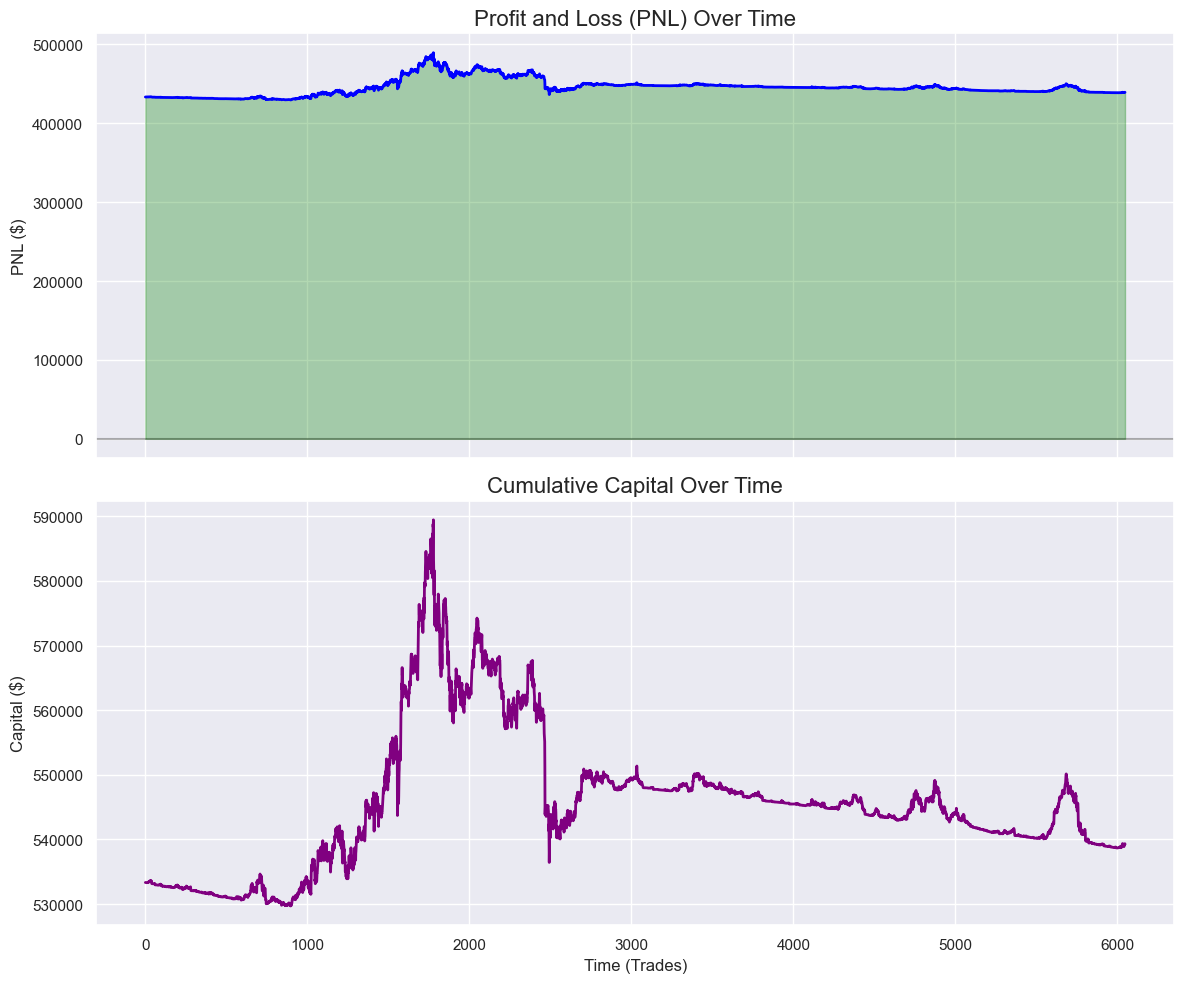

<Figure size 1200x600 with 0 Axes>

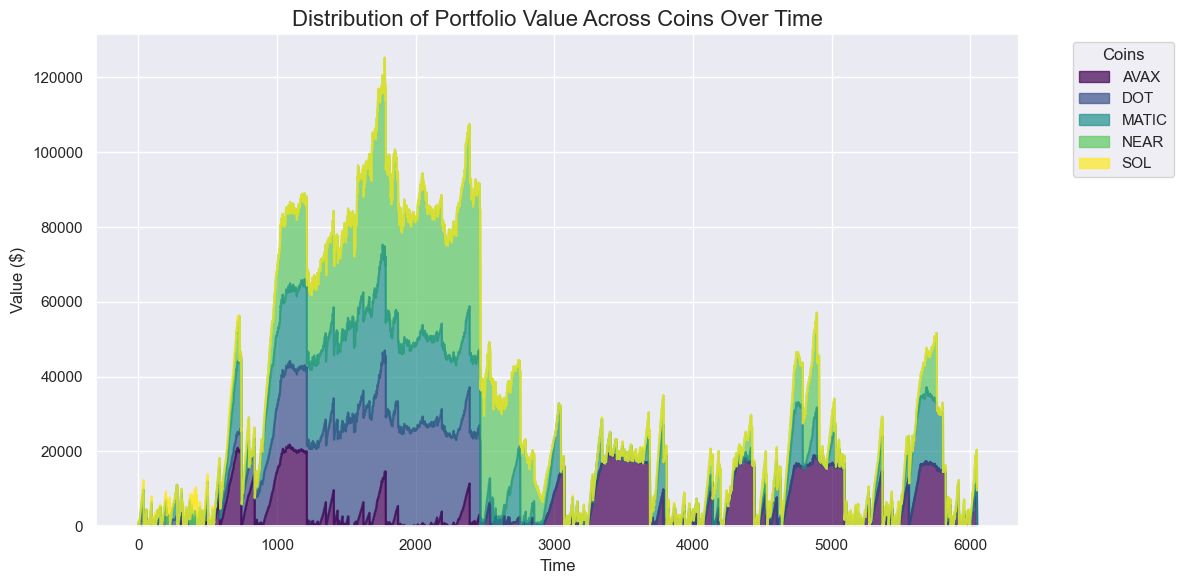

KeyboardInterrupt: 

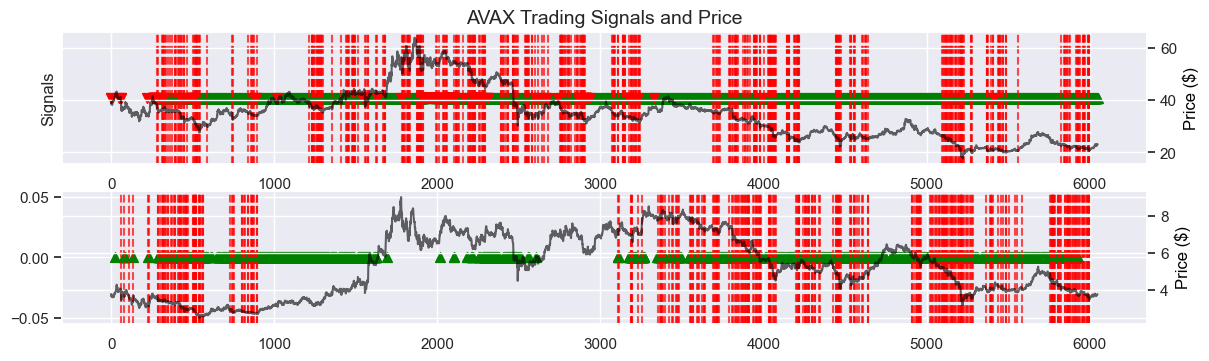

In [55]:
results, pnl, cumulative_capital = run_portfolio_analysis_with_seaborn(dfs, price_dfs)

    Coin Initial Investment  Final Value         PNL  PNL (%)
1   NEAR         $20,000.00   $39,425.73  $19,425.73   97.13%
2    SOL         $20,000.00   $19,631.38    $-368.62   -1.84%
3    DOT         $20,000.00   $18,469.45  $-1,530.55   -7.65%
0   AVAX         $20,000.00   $14,330.13  $-5,669.87  -28.35%
4  MATIC         $20,000.00   $14,141.56  $-5,858.44  -29.29%
5  TOTAL        $100,000.00  $105,998.25   $5,998.25    6.00%


/var/folders/hq/47ww7tn11ss9dm7r1n54_hlr0000gn/T/ipykernel_54438/102455657.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Coin', y='PNL_numeric', data=plot_df, palette=colors)


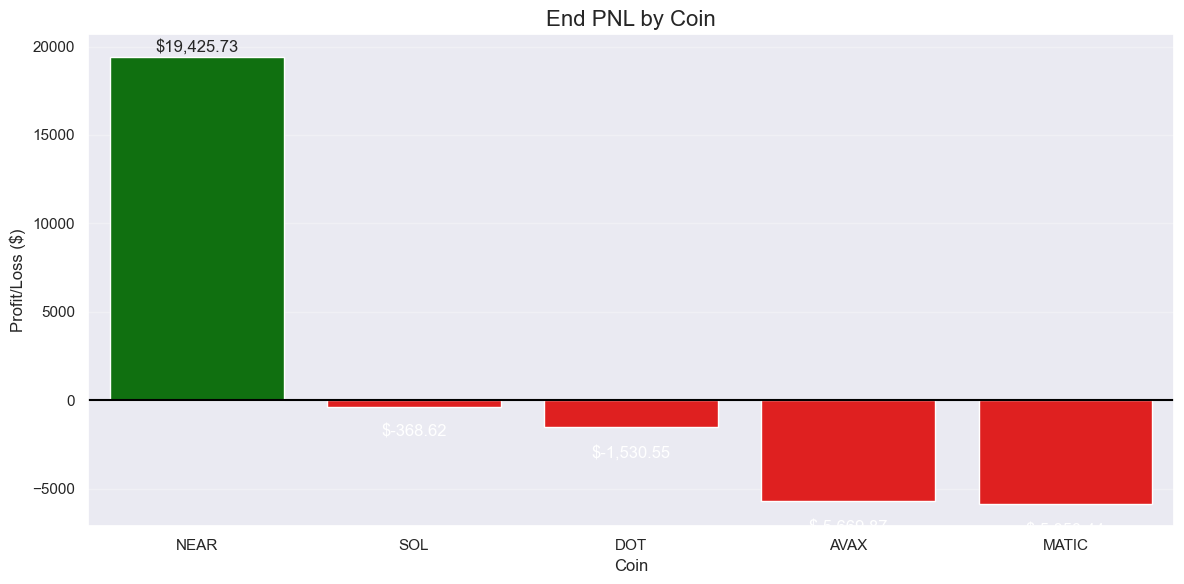

In [54]:
def display_end_pnl_by_coin(results, price_dfs, starting_capital):
    """
    Calculate and display the final PNL for each coin in the portfolio.

    Parameters:
    results (dict): Dictionary of DataFrames with portfolio results for each coin
    price_dfs (dict): Dictionary of DataFrames containing price data for each coin
    starting_capital (float): Initial investment amount

    Returns:
    pd.DataFrame: DataFrame containing end PNL for each coin
    """
    # Calculate initial investment per coin
    coin_names = list(results.keys())
    initial_investment_per_coin = starting_capital / len(coin_names)

    # Prepare data for final PNL calculation
    end_pnl_data = []

    for coin, result_df in results.items():
        # Get the last row for final values
        final_row = result_df.iloc[-1]

        # Calculate end value (cash + holdings)
        end_value = final_row['Cash Holdings'] + final_row['Coin Value']

        # Calculate PNL
        coin_pnl = end_value - initial_investment_per_coin
        coin_pnl_percentage = (coin_pnl / initial_investment_per_coin) * 100

        end_pnl_data.append({
            'Coin': coin,
            'Initial Investment': initial_investment_per_coin,
            'Final Value': end_value,
            'PNL': coin_pnl,
            'PNL (%)': coin_pnl_percentage
        })

    # Create DataFrame and sort by PNL
    end_pnl_df = pd.DataFrame(end_pnl_data)
    end_pnl_df = end_pnl_df.sort_values('PNL', ascending=False)

    # Calculate total portfolio PNL
    total_end_value = sum(row['Final Value'] for row in end_pnl_data)
    total_pnl = total_end_value - starting_capital
    total_pnl_percentage = (total_pnl / starting_capital) * 100

    # Add total row
    end_pnl_df.loc[len(end_pnl_df)] = {
        'Coin': 'TOTAL',
        'Initial Investment': starting_capital,
        'Final Value': total_end_value,
        'PNL': total_pnl,
        'PNL (%)': total_pnl_percentage
    }

    # Format the DataFrame for display
    formatted_df = end_pnl_df.copy()
    formatted_df['Initial Investment'] = formatted_df['Initial Investment'].map('${:,.2f}'.format)
    formatted_df['Final Value'] = formatted_df['Final Value'].map('${:,.2f}'.format)
    formatted_df['PNL'] = formatted_df['PNL'].map('${:,.2f}'.format)
    formatted_df['PNL (%)'] = formatted_df['PNL (%)'].map('{:,.2f}%'.format)

    return formatted_df

# To use this function:
end_pnl_df = display_end_pnl_by_coin(results, price_dfs, starting_capital)
print(end_pnl_df)

# If you want to display it in a visually appealing way with a bar chart:
def plot_end_pnl_by_coin(end_pnl_df):
    """
    Create a bar chart visualization of the end PNL for each coin.
    """
    # Create a copy without the TOTAL row for plotting
    plot_df = end_pnl_df[end_pnl_df['Coin'] != 'TOTAL'].copy()

    # Convert PNL strings back to numeric for plotting
    plot_df['PNL_numeric'] = plot_df['PNL'].str.replace('$', '').str.replace(',', '').astype(float)

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Create bars with different colors based on positive/negative PNL
    colors = ['green' if x >= 0 else 'red' for x in plot_df['PNL_numeric']]

    # Create the bar chart
    ax = sns.barplot(x='Coin', y='PNL_numeric', data=plot_df, palette=colors)

    # Add value labels on top of each bar
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        if height < 0:
            ax.text(p.get_x() + p.get_width()/2., height - 1000,
                   plot_df['PNL'].iloc[i],
                   ha="center", va="top", color='white')
        else:
            ax.text(p.get_x() + p.get_width()/2., height + 100,
                   plot_df['PNL'].iloc[i],
                   ha="center", va="bottom")

    # Customize the plot
    plt.title('End PNL by Coin', fontsize=16)
    plt.xlabel('Coin', fontsize=12)
    plt.ylabel('Profit/Loss ($)', fontsize=12)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# To show the chart:
plot_end_pnl_by_coin(end_pnl_df)